In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import utils
from external.api_repo.generators import single_well_generator
import pmdarima as pm
from torchmetrics.functional.regression import continuous_ranked_probability_score

linear+noise: $x(t+\Delta t)=x(t)+\epsilon, \epsilon\sim \mathcal{N}(0,1)$

single well: $x(t+\Delta t)=x(t)-\frac{\Delta t}{\gamma}\nabla_x U(x(t))+F_{rand}$

double well: $x(t+\Delta t)=x(t)-\frac{\Delta t}{\gamma}\nabla_x U(x(t))+F_{rand}$

In [209]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

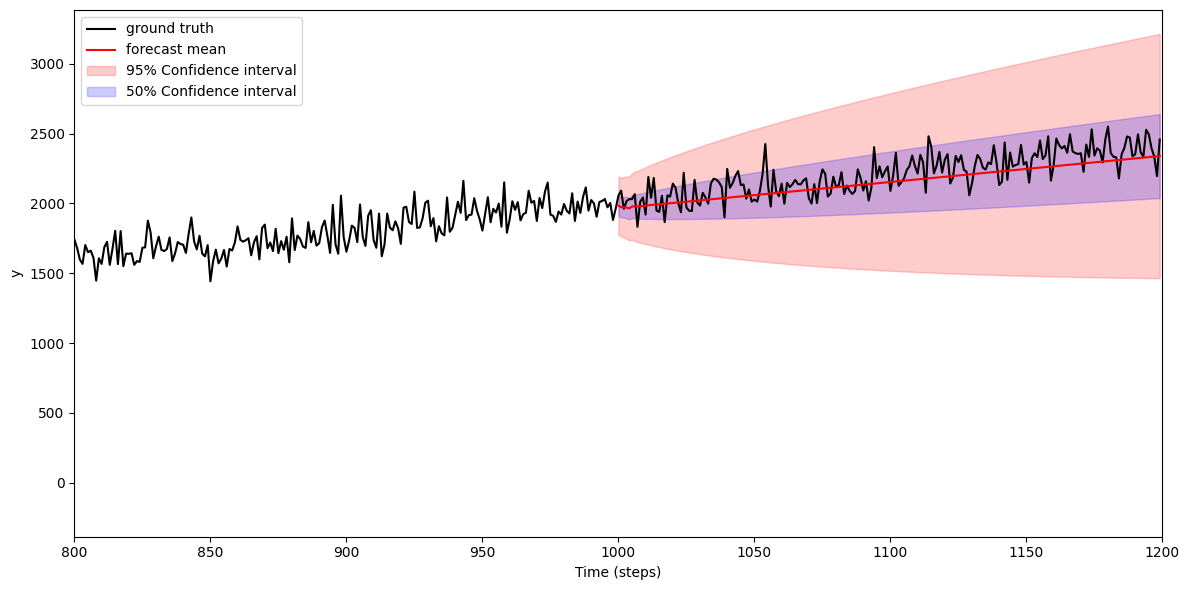

In [210]:
np.random.seed(0)

def process(n,split=-1,slope=1,intercept=0,noise=0.2):
    t = np.arange(n)
    if split==-1:
        return np.array(slope*t+intercept) + noise*np.random.randn(n)
    else:
        return (np.array(slope*t+intercept) + noise*np.random.randn(n))[split:]

n = 1200

signal = process(n,slope=2,intercept=0,noise=100)
data=pd.Series(signal)

split = 1000

model = pm.auto_arima(data.iloc[:split], suppress_warnings=True)
result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci95 = forecast_res.conf_int(alpha=0.05)
ci95.index = test.index

plt.figure(figsize=(12, 6))
plt.plot(data.index, data, color="black", label="ground truth")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

plt.fill_between(ci95.index, ci95.iloc[:, 0], ci95.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index

plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.xlabel("Time (steps)")
plt.ylabel("y")
plt.xlim(800,1200)

plt.legend()
plt.tight_layout()
plt.show()

torch.Size([20000, 200])
torch.Size([200])


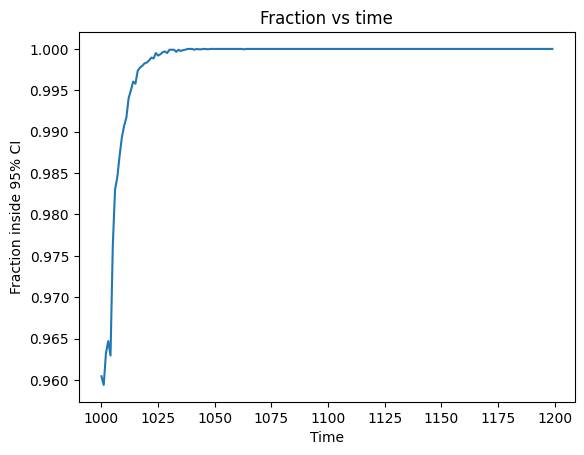

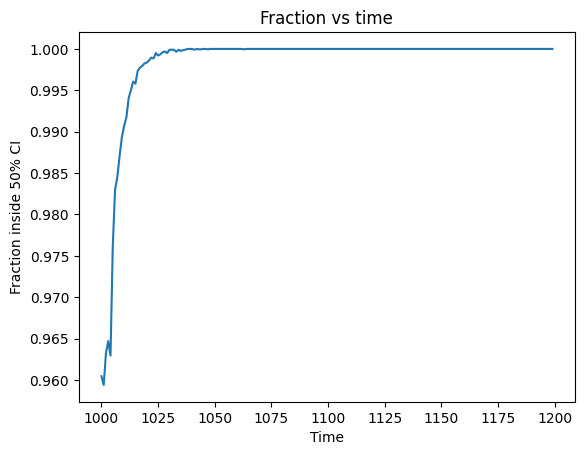

In [211]:
n_traj = 20000
trajs = [process(n,slope=2,intercept=0,noise=100,split=split) for _ in range(n_traj)]

trajectories = torch.stack([torch.tensor(traj) for traj in trajs])
ci_lower = torch.tensor(ci95.iloc[:, 0].values)
ci_upper = torch.tensor(ci95.iloc[:, 1].values)

print(trajectories.shape)
print(ci_lower.shape)

values=utils.fractionMetric(trajectories, ci_lower=ci_lower,ci_upper=ci_upper)

plt.plot(test.index, values.detach().cpu().numpy())
plt.ylabel("Fraction inside 95% CI")
plt.xlabel("Time")
plt.title("Fraction vs time")
plt.show()

ci_lower = torch.tensor(ci50.iloc[:, 0].values)
ci_upper = torch.tensor(ci50.iloc[:, 1].values)

plt.plot(test.index, values.detach().cpu().numpy())
plt.ylabel("Fraction inside 50% CI")
plt.xlabel("Time")
plt.title("Fraction vs time")
plt.show()

In [212]:
def process(t,n,split=-1,lower=80,upper=120,noise=0.2):
    if split==-1:
        return np.sin(2*np.pi*t/np.random.randint(lower,upper)) + noise*np.random.randn(n)
    else:
        return (np.sin(2*np.pi*t/np.random.randint(lower,upper) + noise*np.random.randn(n)))[split:]

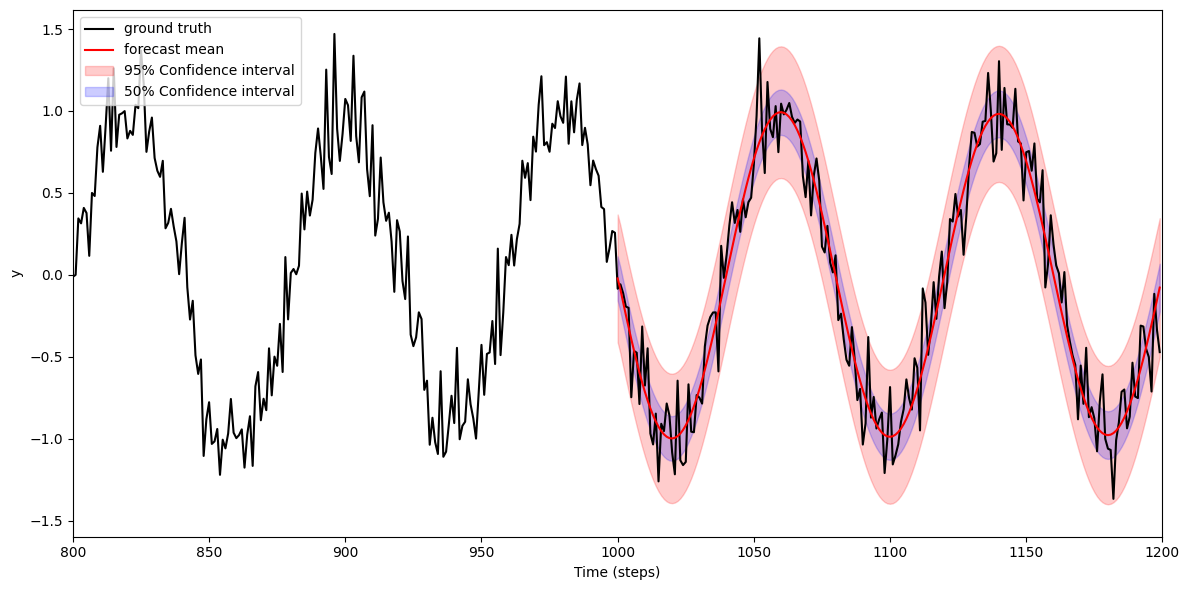

In [213]:
np.random.seed(0)

n = 1200
t = np.arange(n)

signal = process(t,n)
data=pd.Series(signal)

split = 1000

model = pm.auto_arima(data.iloc[:split], suppress_warnings=True)
result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci95 = forecast_res.conf_int(alpha=0.05)
ci95.index = test.index

plt.figure(figsize=(12, 6))
plt.plot(data.index, data, color="black", label="ground truth")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

plt.fill_between(ci95.index, ci95.iloc[:, 0], ci95.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index

plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.xlabel("Time (steps)")
plt.ylabel("y")
plt.xlim(800,1200)

plt.legend()
plt.tight_layout()
plt.show()

In [214]:
n_traj = 20000
trajs = [process(t,n,split=split,lower=80,upper=81,noise=0.3) for _ in range(n_traj)]

torch.Size([20000, 200])
torch.Size([200])


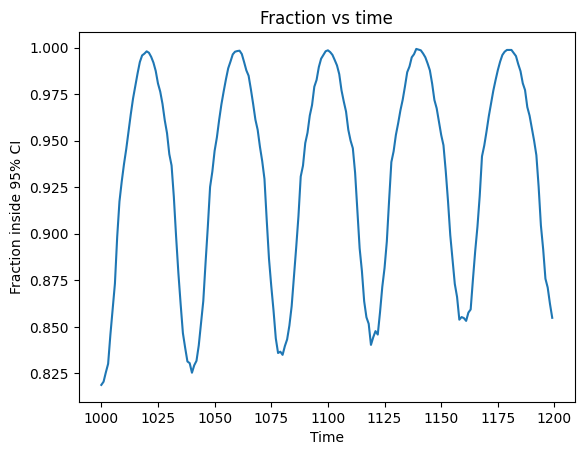

In [215]:
trajectories = torch.stack([torch.tensor(traj) for traj in trajs])
ci_lower = torch.tensor(ci95.iloc[:, 0].values)
ci_upper = torch.tensor(ci95.iloc[:, 1].values)

print(trajectories.shape)
print(ci_lower.shape)

values=utils.fractionMetric(trajectories, ci_lower=ci_lower,ci_upper=ci_upper)

plt.plot(test.index, values.detach().cpu().numpy())
plt.ylabel("Fraction inside 95% CI")
plt.xlabel("Time")
plt.title("Fraction vs time")
plt.show()

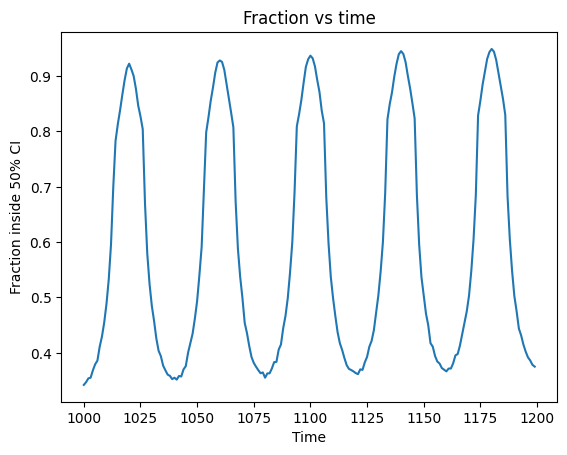

In [216]:
ci_lower = torch.tensor(ci50.iloc[:, 0].values)
ci_upper = torch.tensor(ci50.iloc[:, 1].values)

values=utils.fractionMetric(trajectories, ci_lower=ci_lower,ci_upper=ci_upper)

plt.plot(test.index, values.detach().cpu().numpy())
plt.ylabel("Fraction inside 50% CI")
plt.xlabel("Time")
plt.title("Fraction vs time")
plt.show()

In [217]:
boltzman= 1.38e-11
zeta = 2.24e-9

T = 300
D = (T*boltzman)/zeta
t0=0
total_time = 1
time_step = 4e-3
k=0.9e-8
x0_mean=0
x_mu=15

print(D)


1.8482142857142856


In [218]:
number_of_simulations=1000
x,times = single_well_generator(
    T=T,
    total_time=total_time,
    time_step=time_step,    
    x0_mean=x0_mean,
    zeta=zeta,
    k=k,
    x_mu=x_mu,
    boltzmann=boltzman,
    device=device,
    num_of_simulations=number_of_simulations
)


data = pd.Series(x[0].detach().cpu().numpy())

In [219]:
split = 100
model = pm.auto_arima(data.iloc[:split], suppress_warnings=True)
result = model.arima_res_

steps = len(data) - split
forecast_res = result.get_forecast(steps=steps)
ci95 = forecast_res.conf_int(alpha=0.05)
ci95.index = data.index[split:]
test =data.iloc[split:]
print(test.shape)

(150,)


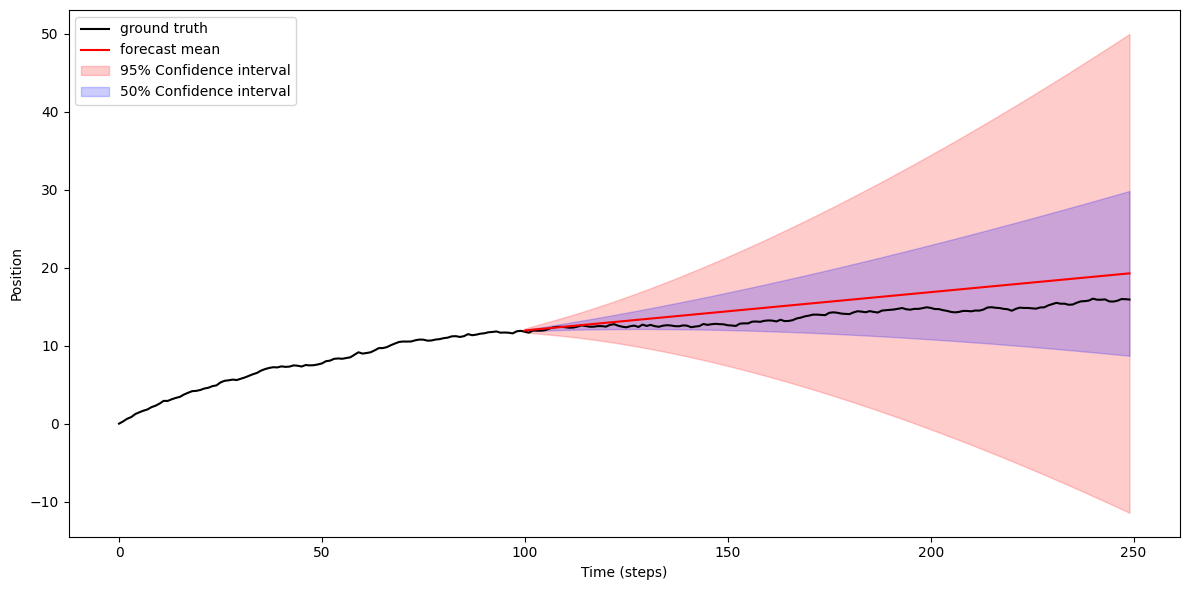

In [220]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data, color="black", label="ground truth")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

plt.fill_between(ci95.index, ci95.iloc[:, 0], ci95.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index

plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.xlabel("Time (steps)")
plt.ylabel("Position")

plt.legend()
plt.tight_layout()
plt.show()

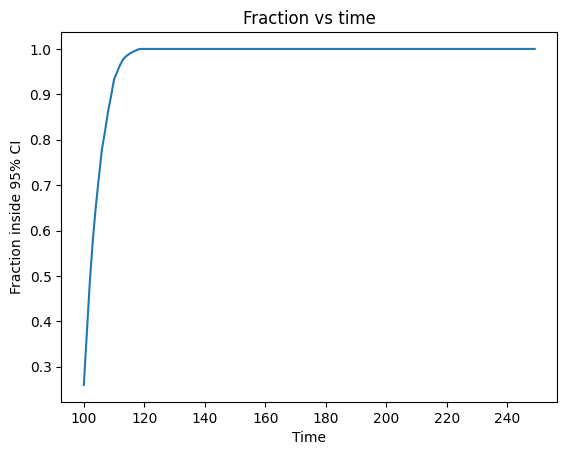

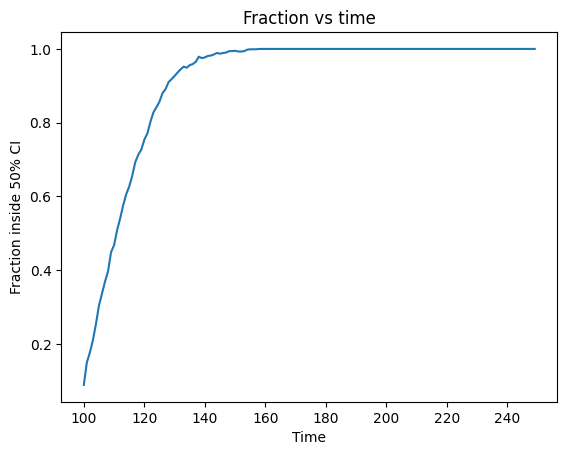

In [221]:
ci_lower = torch.tensor(ci95.iloc[:, 0].values)
ci_upper = torch.tensor(ci95.iloc[:, 1].values)

values=utils.fractionMetric(x[:,split:], ci_lower=ci_lower,ci_upper=ci_upper)

plt.plot(test.index, values.detach().cpu().numpy())
plt.ylabel("Fraction inside 95% CI")
plt.xlabel("Time")
plt.title("Fraction vs time")
plt.show()

values=utils.fractionMetric(x[:,split:], ci_lower=torch.tensor(ci50.iloc[:, 0].values),ci_upper=torch.tensor(ci50.iloc[:, 1].values))

plt.plot(test.index, values.detach().cpu().numpy())
plt.ylabel("Fraction inside 50% CI")
plt.xlabel("Time")
plt.title("Fraction vs time")
plt.show()

<class 'numpy.ndarray'>
<class 'list'>


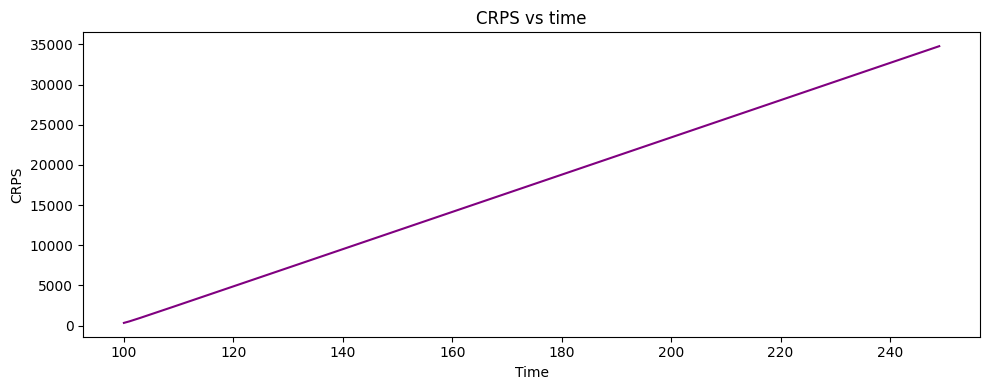

In [222]:
n_sim = 10000
sim_preds = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim_preds.append(torch.tensor(sim.values))

preds=torch.stack(sim_preds)
preds = preds.T    
target = torch.tensor(test.values)

#crps_values = continuous_ranked_probability_score(preds, target)

crps_per_time=[]
for t in range(preds.shape[0]):
    crps_per_time.append(continuous_ranked_probability_score(preds[t].unsqueeze(0),target[t].unsqueeze(0)).detach().cpu().numpy())
plt.figure(figsize=(10, 4))

print(type(test.values))
print(type(crps_per_time))

plt.plot(test.index, crps_per_time, color="purple")
plt.xlabel("Time")
plt.ylabel("CRPS")
plt.title("CRPS vs time")
plt.tight_layout()
plt.show()